### Waveguide Crossing Geometry Analysis (4-port device)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import meep as mp

from crossing import UniformCrossing2D, TaperedCrossing2D
from utils import (
    rect_mask,
    vol_mask,
    pml_mask,
    plot_overlay_masks,
    DEFAULT_OVERLAY_COLORS,
    legend_handles_from_masks,
)

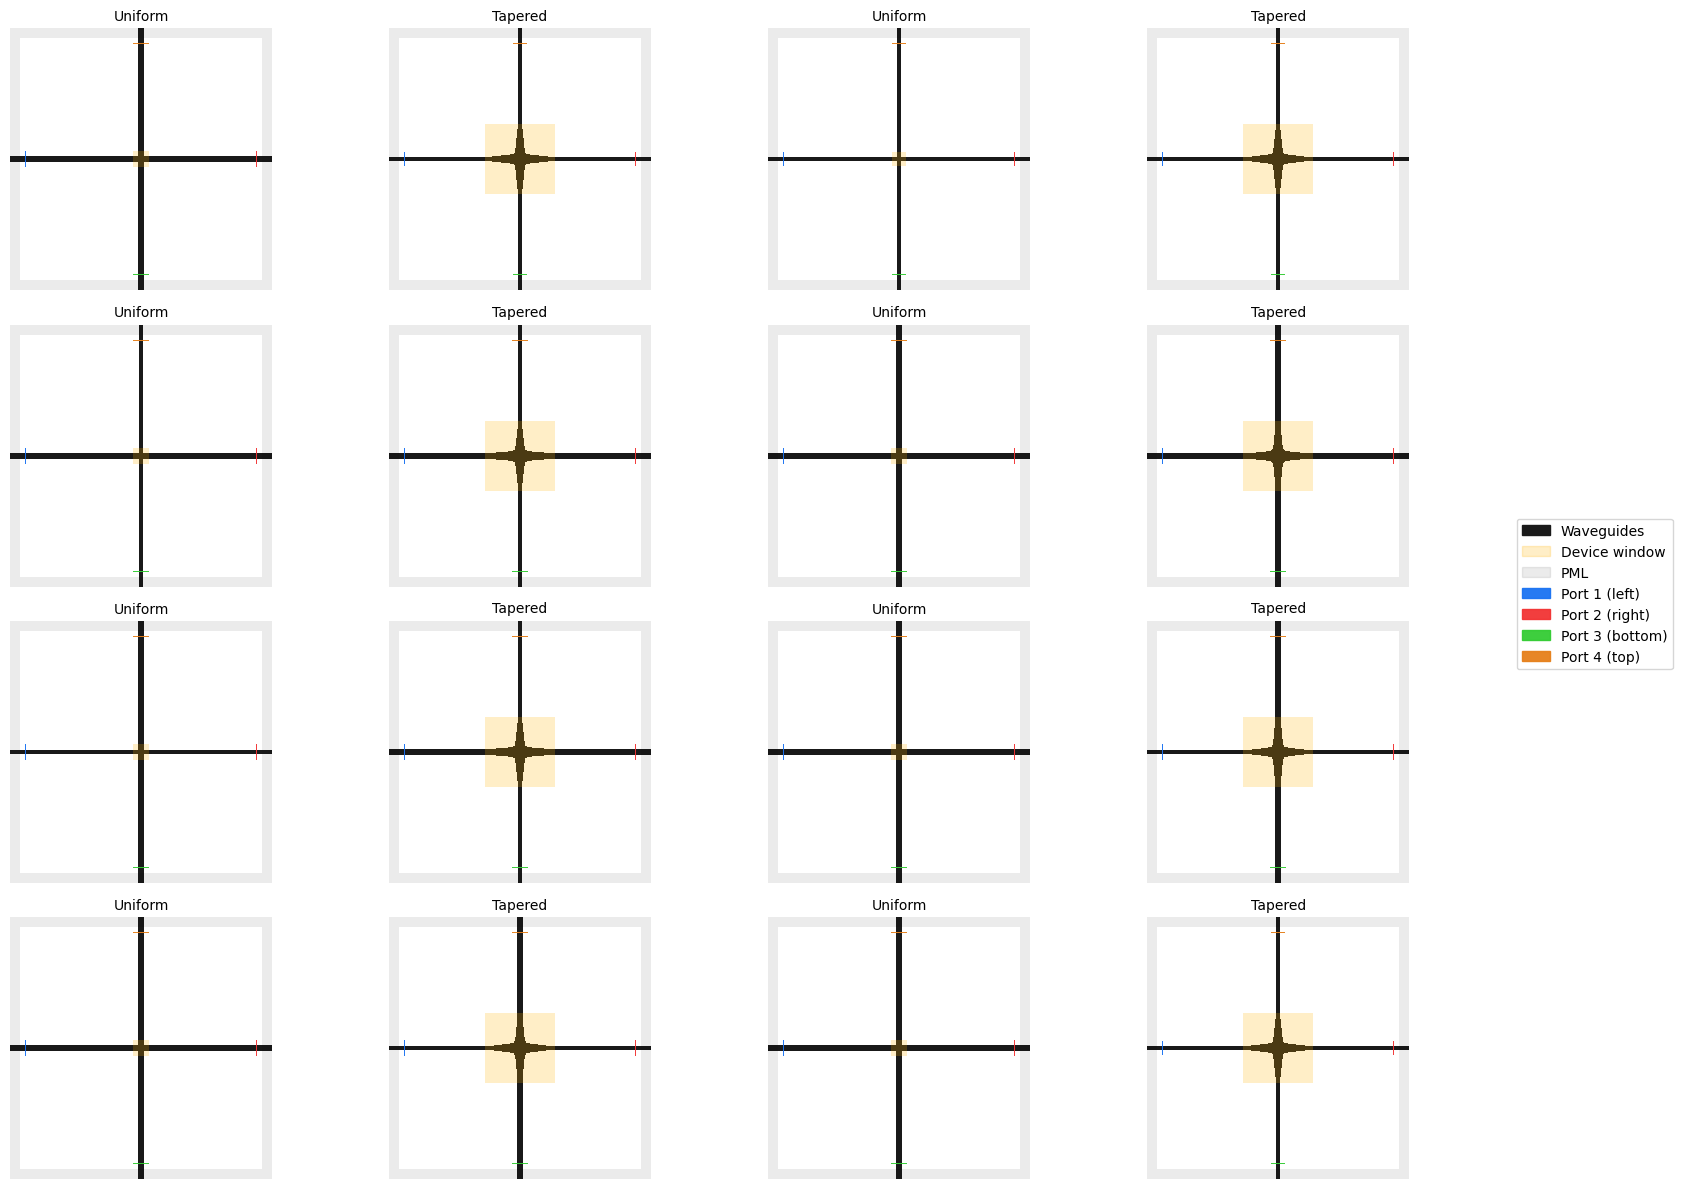

In [6]:
# =========================
# Cell 2: Geometry Sweep (16 geos) - Uniform and Tapered crossings
# =========================
rng = np.random.default_rng(0)
widths_h = rng.uniform(0.38, 0.60, 16)
widths_v = rng.uniform(0.38, 0.60, 16)
lams     = rng.uniform(1.40, 1.60, 16)

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()

for i in range(16):
    # Alternate between Uniform and Tapered crossings
    if i % 2 == 0:
        dev = UniformCrossing2D(
            wg_width_h=float(widths_h[i]),
            wg_width_v=float(widths_v[i]),
            wavelength_um=float(lams[i]),
        )
        label = "Uniform"
    else:
        dev = TaperedCrossing2D(
            wg_width_h=float(widths_h[i]),
            wg_width_v=float(widths_v[i]),
            crossing_width=1.2,
            taper_length_um=3.0,
            wavelength_um=float(lams[i]),
        )
        label = "Tapered"

    nx, ny = dev.nx, dev.ny
    dx = 1.0 / dev.resolution
    dy = 1.0 / dev.resolution

    # Core mask
    core = dev.core_mask(nx, ny, dx, dy)
    if core is None:
        core = rect_mask(nx, ny, dx, dy, dev.dev_cx, dev.dev_cy, dev.dev_wx, dev.dev_wy)

    # Device window + PML
    dev_win = rect_mask(nx, ny, dx, dy, dev.dev_cx, dev.dev_cy, dev.dev_wx, dev.dev_wy)
    pml = pml_mask(nx, ny, dx, dy, dev.cell_x, dev.cell_y, dev.dpml)

    # Ports/sources via base accessors
    ports = dev.get_ports()
    srcs  = dev.get_sources()

    # Custom colors for 4 ports
    port_colors = {
        "port_1": (0.10, 0.45, 0.95, 0.95),  # blue (left)
        "port_2": (0.95, 0.20, 0.20, 0.95),  # red (right)
        "port_3": (0.20, 0.80, 0.20, 0.95),  # green (bottom)
        "port_4": (0.90, 0.50, 0.10, 0.95),  # orange (top)
    }

    masks = {
        "core": core,
        "dev": dev_win,
        "pml": pml,
    }

    for port_name in ["port_1", "port_2", "port_3", "port_4"]:
        if port_name in ports:
            masks[port_name] = vol_mask(nx, ny, dx, dy, ports[port_name])

    colors = DEFAULT_OVERLAY_COLORS.copy()
    colors.update(port_colors)

    draw_order = ["core", "dev", "pml", "port_1", "port_2", "port_3", "port_4"]

    ax = axes[i]
    plot_overlay_masks(ax, masks, colors=colors, draw_order=draw_order,
                       title=f"{label}", show_legend=False)

# Create legend
legend_labels = {
    "core": "Waveguides",
    "dev": "Device window",
    "pml": "PML",
    "port_1": "Port 1 (left)",
    "port_2": "Port 2 (right)",
    "port_3": "Port 3 (bottom)",
    "port_4": "Port 4 (top)",
}

handles = []
for k in draw_order:
    if k in masks:
        handles.append(mpatches.Patch(color=colors[k], label=legend_labels.get(k, k)))

fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=10)

plt.tight_layout()
plt.show()

### S-param Calibration (4-port device)

In [7]:
# =========================
# Cell 3: S-param Calibration (dir_plus/dir_minus discovery for all ports)
# =========================
import numpy as np
import meep as mp

from utils import get_mode_alpha_2dir, pick_in_out_from_alpha

# Create a uniform 90° crossing for calibration
dev = UniformCrossing2D()

# Test with input from port 1 (left)
sim, (m1, m2, m3, m4), dft, fcen = dev._build_sim_single(input_port=1, df_frac=0.1)
sim.run(until_after_sources=mp.stop_when_dft_decayed(tol=1e-6))

# Get alpha for all 4 ports
toward = {1: +1, 2: -1, 3: +1, 4: -1}

print("Input from Port 1 (left, +x direction):")
print("=" * 60)

for port_idx, monitor in [(1, m1), (2, m2), (3, m3), (4, m4)]:
    alpha = np.asarray(get_mode_alpha_2dir(sim, monitor, band=1, eig_parity=mp.NO_PARITY))
    if alpha.ndim == 2:
        alpha = alpha[0]
    
    print(f"\nPort {port_idx}:")
    print(f"  alpha shape = {alpha.shape}")
    print(f"  alpha (two dirs) = {alpha}")
    print(f"  |alpha| = {np.abs(alpha)}")
    
    # Determine which direction has larger amplitude
    dir_plus = int(np.argmax(np.abs(alpha)))
    dir_minus = 1 - dir_plus
    print(f"  Suggested: dir_plus={dir_plus}, dir_minus={dir_minus}")
    
    a_in, b_out = pick_in_out_from_alpha(alpha, toward[port_idx], dir_plus=dir_plus, dir_minus=dir_minus)
    print(f"  a_in (incoming) = {a_in:.6f}")
    print(f"  b_out (outgoing) = {b_out:.6f}")

sim.reset_meep()

# For symmetric crossing, we typically expect:
# - Port 1: small a_in (this is source), large b_out (reflection)
# - Port 2: small a_in, large b_out (main transmission)
# - Port 3&4: small a_in, medium b_out (crosstalk)

# Set calibrated values (adjust based on output above)
DIR_PLUS = 0
DIR_MINUS = 1

print("\n" + "="*60)
print(f"Using DIR_PLUS={DIR_PLUS}, DIR_MINUS={DIR_MINUS} for all ports")

-----------
Initializing structure...
time for choose_chunkdivision = 0.00352693 s
Working in 2D dimensions.
Computational cell is 26 x 26 x 0 with resolution 18
     block, center = (0,0,0)
          size (1e+20,0.45,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
     block, center = (0,0,0)
          size (0.45,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
time for set_epsilon = 0.359563 s
-----------


MPB solved for frequency_1(1,0,0) = 0.513902 after 15 iters
MPB solved for frequency_1(1.29446,0,0) = 0.643203 after 7 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 5 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 1 iters
on time step 533 (time=14.8056), 0.00751562 s/step
on time step 1059 (time=29.4167), 0.00760839 s/step
on time step 1602 (time=44.5), 0.00737171 s/step
on time step 2139 (time=59.4167), 0.00745555 s/step
on time step 2671 (time=74.1944), 0.00753033 s/step
on time step 3218 (time=89.3889), 0.00731588 s/step
on time step 3755 (time=104.306), 0.00744994 s/step
on time step 4318 (time=119.944), 0.00711375 s/step
on time step 4858 (time=134.944), 0.00741625 s/step
on time step 5432 (time=150.889), 0.00697926 s/step
on time step 5993 (time=166.472), 0.00713803 s/step
on time step 6529 (time=181.361), 0.00747039 s/step
on time step 7102 (time=197.278), 0.00698576 s/step
on time step 7645 (time=212.361), 0.0073698 s/step


run 0 finished at t = 216.25 (7785 timesteps)
Input from Port 1 (left, +x direction):
MPB solved for frequency_1(1.4664,0,0) = 0.717675 after 17 iters
MPB solved for frequency_1(1.29855,0,0) = 0.64498 after 6 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.298968,-0.000000,0.000000)



Port 1:
  alpha shape = (2,)
  alpha (two dirs) = [-9.27120081-12.55401246j -0.00960306 -0.859972j  ]
  |alpha| = [15.60635746  0.86002561]
  Suggested: dir_plus=0, dir_minus=1
  a_in (incoming) = -9.271201-12.554012j
  b_out (outgoing) = -0.009603-0.859972j
MPB solved for frequency_1(1.4664,0,0) = 0.717675 after 17 iters
MPB solved for frequency_1(1.29855,0,0) = 0.64498 after 6 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.298968,-0.000000,0.000000)



Port 2:
  alpha shape = (2,)
  alpha (two dirs) = [13.52253282-4.32773494j -0.2089423 +0.06734316j]
  |alpha| = [14.19817536  0.21952673]
  Suggested: dir_plus=0, dir_minus=1
  a_in (incoming) = -0.208942+0.067343j
  b_out (outgoing) = 13.522533-4.327735j
MPB solved for frequency_1(0,1.4664,0) = 0.717675 after 17 iters
MPB solved for frequency_1(0,1.29855,0) = 0.64498 after 6 iters
MPB solved for frequency_1(0,1.29897,0) = 0.645161 after 4 iters
MPB solved for frequency_1(0,1.29897,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (0.000000,1.298968,0.000000)



Port 3:
  alpha shape = (2,)
  alpha (two dirs) = [-0.01567901-0.03421374j  1.01620154+2.2273259j ]
  |alpha| = [0.03763524 2.44819244]
  Suggested: dir_plus=1, dir_minus=0
  a_in (incoming) = 1.016202+2.227326j
  b_out (outgoing) = -0.015679-0.034214j
MPB solved for frequency_1(0,1.4664,0) = 0.717675 after 17 iters
MPB solved for frequency_1(0,1.29855,0) = 0.64498 after 6 iters
MPB solved for frequency_1(0,1.29897,0) = 0.645161 after 4 iters
MPB solved for frequency_1(0,1.29897,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (0.000000,1.298968,0.000000)

Port 4:
  alpha shape = (2,)
  alpha (two dirs) = [ 1.13201673+2.48117396j -0.0174733 -0.03816551j]
  |alpha| = [2.72721215 0.04197526]
  Suggested: dir_plus=0, dir_minus=1
  a_in (incoming) = -0.017473-0.038166j
  b_out (outgoing) = 1.132017+2.481174j

Using DIR_PLUS=0, DIR_MINUS=1 for all ports


-----------
Initializing structure...
time for choose_chunkdivision = 0.000340939 s
Working in 2D dimensions.
Computational cell is 26 x 26 x 0 with resolution 18
     block, center = (0,0,0)
          size (1e+20,0.45,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
     block, center = (0,0,0)
          size (0.45,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
time for set_epsilon = 0.409921 s
-----------


MPB solved for frequency_1(1,0,0) = 0.513902 after 15 iters
MPB solved for frequency_1(1.29446,0,0) = 0.643203 after 7 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 5 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 1 iters
on time step 544 (time=15.1111), 0.00735453 s/step
on time step 1114 (time=30.9444), 0.00701842 s/step
on time step 1690 (time=46.9444), 0.00696047 s/step
on time step 2250 (time=62.5), 0.00715319 s/step
on time step 2825 (time=78.4722), 0.00696337 s/step
on time step 3420 (time=95), 0.00672742 s/step
on time step 4007 (time=111.306), 0.00682218 s/step
on time step 4583 (time=127.306), 0.00694561 s/step
on time step 5164 (time=143.444), 0.00689296 s/step
on time step 5708 (time=158.556), 0.00735937 s/step
on time step 6216 (time=172.667), 0.00787599 s/step
on time step 6701 (time=186.139), 0.00825066 s/step
on time step 7241 (time=201.139), 0.00742046 s/step
on time step 7766 (time=215.722), 0.00763332 s/step
run 0 finished at t = 216.

MPB solved for frequency_1(1.4664,0,0) = 0.717675 after 17 iters
MPB solved for frequency_1(1.29855,0,0) = 0.64498 after 6 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.298968,-0.000000,0.000000)


MPB solved for frequency_1(1.4664,0,0) = 0.717675 after 17 iters
MPB solved for frequency_1(1.29855,0,0) = 0.64498 after 6 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.298968,-0.000000,0.000000)


MPB solved for frequency_1(0,1.4664,0) = 0.717675 after 17 iters
MPB solved for frequency_1(0,1.29855,0) = 0.64498 after 6 iters
MPB solved for frequency_1(0,1.29897,0) = 0.645161 after 4 iters
MPB solved for frequency_1(0,1.29897,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (0.000000,1.298968,0.000000)


...

MPB solved for frequency_1(1,0,0) = 0.513902 after 15 iters
MPB solved for frequency_1(1.29446,0,0) = 0.643203 after 7 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 5 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 1 iters
on time step 484 (time=13.4444), 0.00828114 s/step
on time step 994 (time=27.6111), 0.00785529 s/step
on time step 1475 (time=40.9722), 0.00832781 s/step
on time step 1960 (time=54.4444), 0.00825272 s/step
on time step 2456 (time=68.2222), 0.0080749 s/step
on time step 2981 (time=82.8056), 0.00762001 s/step
on time step 3504 (time=97.3333), 0.0076619 s/step
on time step 4007 (time=111.306), 0.00796867 s/step
on time step 4522 (time=125.611), 0.00778514 s/step
on time step 5038 (time=139.944), 0.00776323 s/step
on time step 5545 (time=154.028), 0.00790177 s/step
on time step 6043 (time=167.861), 0.00804279 s/step
on time step 6557 (time=182.139), 0.00778251 s/step
on time step 7069 (time=196.361), 0.00782098 s/step


run 0 finished at t = 199.13888888888889 (7169 timesteps)
MPB solved for frequency_1(1.4664,0,0) = 0.717675 after 17 iters
MPB solved for frequency_1(1.29855,0,0) = 0.64498 after 6 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.298968,-0.000000,0.000000)


MPB solved for frequency_1(1.4664,0,0) = 0.717675 after 17 iters
MPB solved for frequency_1(1.29855,0,0) = 0.64498 after 6 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.29897,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.298968,-0.000000,0.000000)


MPB solved for frequency_1(0,1.4664,0) = 0.717675 after 17 iters
MPB solved for frequency_1(0,1.29855,0) = 0.64498 after 6 iters
MPB solved for frequency_1(0,1.29897,0) = 0.645161 after 4 iters
MPB solved for frequency_1(0,1.29897,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (0.000000,1.298968,0.000000)


MPB solved for frequency_1(0,1.4664,0) = 0.717675 after 17 iters
MPB solved for frequency_1(0,1.29855,0) = 0.64498 after 6 iters
MPB solved for frequency_1(0,1.29897,0) = 0.645161 after 4 iters
MPB solved for frequency_1(0,1.29897,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (0.000000,1.298968,0.000000)

=== S-parameters (Tapered, Input from Port 1) ===
S11 (reflection)     = -0.063145-0.016282j,  |S11|² = 0.004252
S21 (through)        = 0.126791-0.909453j,  |S21|² = 0.843181
S31 (crosstalk)      = 0.024663+0.013892j,  |S31|² = 0.000801
S41 (crosstalk)      = 0.027476+0.015475j,  |S41|² = 0.000994

Through loss:     0.74 dB
Crosstalk (Port 3): 30.96 dB
Crosstalk (Port 4): 30.02 dB

Power conservation: 0.849229


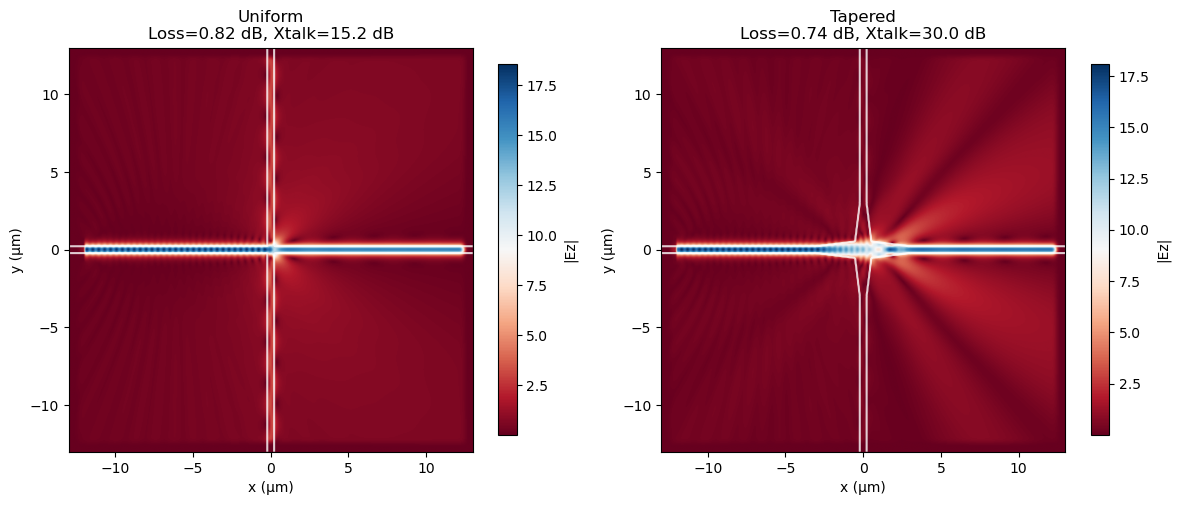

In [10]:
# =========================
# Cell 4: Single-frequency S-parameters (input from Port 1)
# =========================
# Uniform crossing
uniform = UniformCrossing2D(
    wg_width_h=0.45,
    wg_width_v=0.45,
    wavelength_um=1.55,
)

eps_u, Ez_u, S_u, (cell_x, cell_y) = uniform.run_sim(
    input_port=1,
    decay_tol=1e-6,
    dir_plus=DIR_PLUS,
    dir_minus=DIR_MINUS,
)

print("\n=== S-parameters (Uniform, Input from Port 1) ===")
print(f"S11 (reflection)     = {S_u['S11']:.6f},  |S11|² = {abs(S_u['S11'])**2:.6f}")
print(f"S21 (through)        = {S_u['S21']:.6f},  |S21|² = {abs(S_u['S21'])**2:.6f}")
print(f"S31 (crosstalk)      = {S_u['S31']:.6f},  |S31|² = {abs(S_u['S31'])**2:.6f}")
print(f"S41 (crosstalk)      = {S_u['S41']:.6f},  |S41|² = {abs(S_u['S41'])**2:.6f}")
print(f"\nThrough loss:     {-10*np.log10(abs(S_u['S21'])**2):.2f} dB")
print(f"Crosstalk (Port 3): {-10*np.log10(abs(S_u['S31'])**2):.2f} dB")
print(f"Crosstalk (Port 4): {-10*np.log10(abs(S_u['S41'])**2):.2f} dB")
print(f"\nPower conservation: {abs(S_u['S11'])**2 + abs(S_u['S21'])**2 + abs(S_u['S31'])**2 + abs(S_u['S41'])**2:.6f}")

# Tapered crossing
TAPERED_CROSSING_WIDTH = 1.2
TAPERED_TAPER_LEN_UM = 3.0

tapered = TaperedCrossing2D(
    wg_width_h=0.45,
    wg_width_v=0.45,
    crossing_width=TAPERED_CROSSING_WIDTH,
    taper_length_um=TAPERED_TAPER_LEN_UM,
    wavelength_um=1.55,
)

eps_t, Ez_t, S_t, _ = tapered.run_sim(
    input_port=1,
    decay_tol=1e-6,
    dir_plus=DIR_PLUS,
    dir_minus=DIR_MINUS,
)

print("\n=== S-parameters (Tapered, Input from Port 1) ===")
print(f"S11 (reflection)     = {S_t['S11']:.6f},  |S11|² = {abs(S_t['S11'])**2:.6f}")
print(f"S21 (through)        = {S_t['S21']:.6f},  |S21|² = {abs(S_t['S21'])**2:.6f}")
print(f"S31 (crosstalk)      = {S_t['S31']:.6f},  |S31|² = {abs(S_t['S31'])**2:.6f}")
print(f"S41 (crosstalk)      = {S_t['S41']:.6f},  |S41|² = {abs(S_t['S41'])**2:.6f}")
print(f"\nThrough loss:     {-10*np.log10(abs(S_t['S21'])**2):.2f} dB")
print(f"Crosstalk (Port 3): {-10*np.log10(abs(S_t['S31'])**2):.2f} dB")
print(f"Crosstalk (Port 4): {-10*np.log10(abs(S_t['S41'])**2):.2f} dB")
print(f"\nPower conservation: {abs(S_t['S11'])**2 + abs(S_t['S21'])**2 + abs(S_t['S31'])**2 + abs(S_t['S41'])**2:.6f}")

# Field plots for this single-frequency run (Uniform + Tapered)
extent = [-0.5 * cell_x, 0.5 * cell_x, -0.5 * cell_y, 0.5 * cell_y]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Uniform
ax = axes[0]
im = ax.imshow(np.abs(Ez_u), origin="lower", extent=extent, aspect="equal", cmap="RdBu")
eps_level = 0.5 * (np.min(eps_u) + np.max(eps_u))
ax.contour(eps_u, levels=[eps_level], colors="white", linewidths=1.5, alpha=0.8, extent=extent)
through_loss_u = -10*np.log10(abs(S_u['S21'])**2 + 1e-12)
xtalk_u = -10*np.log10(max(abs(S_u['S31'])**2, abs(S_u['S41'])**2) + 1e-12)
ax.set_title(f"Uniform\nLoss={through_loss_u:.2f} dB, Xtalk={xtalk_u:.1f} dB")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
plt.colorbar(im, ax=ax, shrink=0.85, label="|Ez|")

# Tapered
ax = axes[1]
im = ax.imshow(np.abs(Ez_t), origin="lower", extent=extent, aspect="equal", cmap="RdBu")
eps_level = 0.5 * (np.min(eps_t) + np.max(eps_t))
ax.contour(eps_t, levels=[eps_level], colors="white", linewidths=1.5, alpha=0.8, extent=extent)
through_loss_t = -10*np.log10(abs(S_t['S21'])**2 + 1e-12)
xtalk_t = -10*np.log10(max(abs(S_t['S31'])**2, abs(S_t['S41'])**2) + 1e-12)
ax.set_title(f"Tapered\nLoss={through_loss_t:.2f} dB, Xtalk={xtalk_t:.1f} dB")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
plt.colorbar(im, ax=ax, shrink=0.85, label="|Ez|")

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Cell 5: Broadband spectrum (Input from Port 1)
# =========================
import matplotlib.pyplot as plt

dev = UniformCrossing2D(
    wg_width_h=0.45,
    wg_width_v=0.45,
    wavelength_um=1.55,
)

lams, S_spec = dev.run_spectrum(
    input_port=1,
    lam_min_um=1.40,
    lam_max_um=1.60,
    Nf=51,
    decay_tol=1e-6,
    dir_plus=DIR_PLUS,
    dir_minus=DIR_MINUS,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Power transmission
ax = axes[0]
ax.plot(lams, np.abs(S_spec['S21'])**2, label="|S21|² (Through)", linewidth=2, color='C0')
ax.plot(lams, np.abs(S_spec['S11'])**2, label="|S11|² (Reflection)", linewidth=2, color='C1')
ax.plot(lams, np.abs(S_spec['S31'])**2, label="|S31|² (Crosstalk to Port 3)", linewidth=2, color='C2')
ax.plot(lams, np.abs(S_spec['S41'])**2, label="|S41|² (Crosstalk to Port 4)", linewidth=2, color='C3')
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Power")
ax.set_title("Crossing: Power vs Wavelength")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Loss in dB
ax = axes[1]
ax.plot(lams, -10*np.log10(np.abs(S_spec['S21'])**2 + 1e-12), label="Through Loss (dB)", linewidth=2, color='C0')
ax.plot(lams, -10*np.log10(np.abs(S_spec['S31'])**2 + 1e-12), label="Crosstalk to Port 3 (dB)", linewidth=2, color='C2')
ax.plot(lams, -10*np.log10(np.abs(S_spec['S41'])**2 + 1e-12), label="Crosstalk to Port 4 (dB)", linewidth=2, color='C3')
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Loss (dB)")
ax.set_title("Crossing: Loss vs Wavelength")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([-0.5, 50])

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Cell 6: Field patterns - Uniform vs Tapered (input Port 1)
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Uniform crossing
uniform = UniformCrossing2D(wg_width_h=0.45, wg_width_v=0.45, wavelength_um=1.55)
eps_u, Ez_u, S_u, (cell_x, cell_y) = uniform.run_sim(
    input_port=1,
    decay_tol=1e-6,
    dir_plus=DIR_PLUS,
    dir_minus=DIR_MINUS,
)

# Tapered crossing
tapered = TaperedCrossing2D(
    wg_width_h=0.45,
    wg_width_v=0.45,
    crossing_width=1.2,
    taper_length_um=3.0,
    wavelength_um=1.55,
)
eps_t, Ez_t, S_t, _ = tapered.run_sim(
    input_port=1,
    decay_tol=1e-6,
    dir_plus=DIR_PLUS,
    dir_minus=DIR_MINUS,
)

extent = [-0.5 * cell_x, 0.5 * cell_x, -0.5 * cell_y, 0.5 * cell_y]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Uniform
ax = axes[0]
im = ax.imshow(np.abs(Ez_u), origin="lower", extent=extent, aspect="equal", cmap="RdBu")
eps_level = 0.5 * (np.min(eps_u) + np.max(eps_u))
ax.contour(eps_u, levels=[eps_level], colors="white", linewidths=1.5, alpha=0.8, extent=extent)
through_loss_u = -10*np.log10(abs(S_u['S21'])**2 + 1e-12)
xtalk_u = -10*np.log10(max(abs(S_u['S31'])**2, abs(S_u['S41'])**2) + 1e-12)
ax.set_title(f"Uniform\nLoss={through_loss_u:.2f} dB, Xtalk={xtalk_u:.1f} dB")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
plt.colorbar(im, ax=ax, shrink=0.8, label="|Ez|")

# Tapered
ax = axes[1]
im = ax.imshow(np.abs(Ez_t), origin="lower", extent=extent, aspect="equal", cmap="RdBu")
eps_level = 0.5 * (np.min(eps_t) + np.max(eps_t))
ax.contour(eps_t, levels=[eps_level], colors="white", linewidths=1.5, alpha=0.8, extent=extent)
through_loss_t = -10*np.log10(abs(S_t['S21'])**2 + 1e-12)
xtalk_t = -10*np.log10(max(abs(S_t['S31'])**2, abs(S_t['S41'])**2) + 1e-12)
ax.set_title(f"Tapered\nLoss={through_loss_t:.2f} dB, Xtalk={xtalk_t:.1f} dB")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
plt.colorbar(im, ax=ax, shrink=0.8, label="|Ez|")

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Cell 7: Reciprocity check (input from different ports)
# =========================
dev = UniformCrossing2D(
    wg_width_h=0.45,
    wg_width_v=0.45,
    wavelength_um=1.55,
)

print("\n=== Reciprocity Check (90° crossing) ===")
print("Testing S-parameter reciprocity: Sij should equal Sji\n")

# Input from Port 1
_, _, S1, _ = dev.run_sim(input_port=1, decay_tol=1e-6, dir_plus=DIR_PLUS, dir_minus=DIR_MINUS)
S21_from_1 = S1['S21']
S31_from_1 = S1['S31']

# Input from Port 2
_, _, S2, _ = dev.run_sim(input_port=2, decay_tol=1e-6, dir_plus=DIR_PLUS, dir_minus=DIR_MINUS)
S12_from_2 = S2['S12']
S32_from_2 = S2['S32']

# Input from Port 3
_, _, S3, _ = dev.run_sim(input_port=3, decay_tol=1e-6, dir_plus=DIR_PLUS, dir_minus=DIR_MINUS)
S13_from_3 = S3['S13']
S23_from_3 = S3['S23']

print("S21 vs S12:")
print(f"  S21 = {S21_from_1:.6f}  (input port 1)")
print(f"  S12 = {S12_from_2:.6f}  (input port 2)")
print(f"  Difference: {abs(S21_from_1 - S12_from_2):.2e}\n")

print("S31 vs S13:")
print(f"  S31 = {S31_from_1:.6f}  (input port 1)")
print(f"  S13 = {S13_from_3:.6f}  (input port 3)")
print(f"  Difference: {abs(S31_from_1 - S13_from_3):.2e}\n")

print("S32 vs S23:")
print(f"  S32 = {S32_from_2:.6f}  (input port 2)")
print(f"  S23 = {S23_from_3:.6f}  (input port 3)")
print(f"  Difference: {abs(S32_from_2 - S23_from_3):.2e}")